<a href="https://colab.research.google.com/github/ANJALICHAMOLI/PyTorch/blob/main/9_ann_pipeline_with__gpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from torchvision import datasets,transforms

torch.manual_seed(42)
transform = transforms.ToTensor() #changes an image into a Pytorch tensor

train_ds = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.2MB/s]


In [ ]:
images = train_ds.data
labels = train_ds.targets

In [ ]:
images = images.view(60000, -1)

In [ ]:
print(images.shape)
print(labels.shape)

torch.Size([60000, 784])
torch.Size([60000])


In [ ]:
pix_col = [f'pixel{i}' for i in range(1,785)]
df = pd.DataFrame(images, columns=pix_col)
df["label"] = labels

In [ ]:
df.shape

(60000, 785)

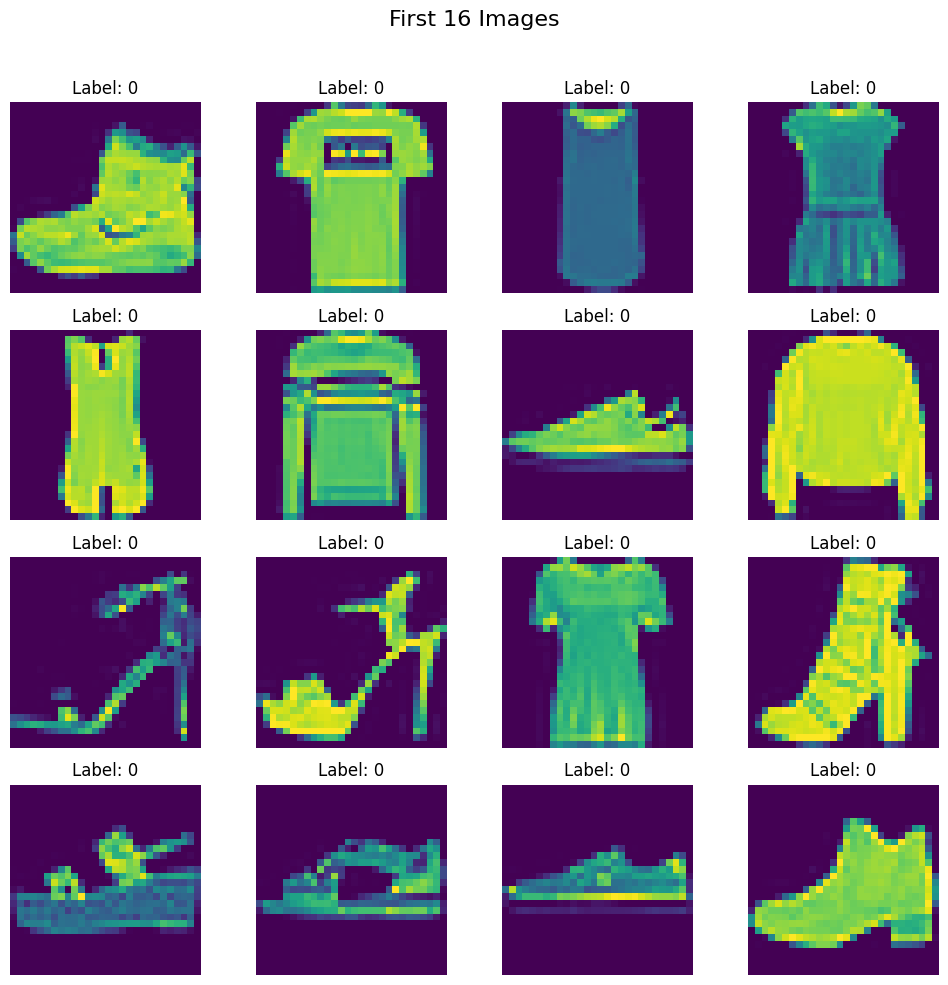

In [ ]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, :-1].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [ ]:
# train test split

X = df.iloc[:, :-1].values
y = df.iloc[:,-1].values

In [ ]:
print(df.columns)

Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10',
       ...
       'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780', 'pixel781',
       'pixel782', 'pixel783', 'pixel784', 'label'],
      dtype='object', length=785)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train, y_train)

In [ ]:
test_dataset = CustomDataset(X_test, y_test)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [ ]:
len(train_loader)

1500

In [ ]:
class NN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)

    )

  def forward(self, x):

    return self.model(x)


In [ ]:
learning_rate = 0.1
epochs = 100

In [ ]:
# instatiate the model
model = NN(X_train.shape[1])
model = model.to(device) #moving model to gpu
# loss function
criterion = nn.CrossEntropyLoss()
# optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.632451968073845
Epoch: 2 , Loss: 0.42423885797460875
Epoch: 3 , Loss: 0.37707344102362794
Epoch: 4 , Loss: 0.3505692383944988
Epoch: 5 , Loss: 0.3306067560017109
Epoch: 6 , Loss: 0.31276306728025277
Epoch: 7 , Loss: 0.3012271250014504
Epoch: 8 , Loss: 0.28949173965553443
Epoch: 9 , Loss: 0.27984877410034337
Epoch: 10 , Loss: 0.2689186441724499
Epoch: 11 , Loss: 0.26161499157796303
Epoch: 12 , Loss: 0.2558325493360559
Epoch: 13 , Loss: 0.24598791336019835
Epoch: 14 , Loss: 0.2391159773307542
Epoch: 15 , Loss: 0.23481790202111005
Epoch: 16 , Loss: 0.22742935765596728
Epoch: 17 , Loss: 0.22402629633247853
Epoch: 18 , Loss: 0.21948166126385332
Epoch: 19 , Loss: 0.21208610444267592
Epoch: 20 , Loss: 0.20820540719417235
Epoch: 21 , Loss: 0.20451761147317787
Epoch: 22 , Loss: 0.1968737212413301
Epoch: 23 , Loss: 0.19230211310336986
Epoch: 24 , Loss: 0.19196422683509687
Epoch: 25 , Loss: 0.1841572520726671
Epoch: 26 , Loss: 0.18110836659247675
Epoch: 27 , Loss: 0.17562167461

In [ ]:
model.eval()

NN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8905
